# 101: EarlySign Tutorial: Group Sequential Testing (Two-Proportions) with Adaptive Information Time

This tutorial demonstrates how to run a group sequential test (GST) for a two-proportions A/B experiment using a **ledger-centric** architecture with **adaptive information time calculation**.

We will:
1. Initialize a DuckDB-backed ledger.
2. Iteratively append observation batches (simulated).
3. Update a Wald Z statistic and adaptive Lan–DeMets (OBF/Pocock) boundaries per look.
4. Dynamically calculate information fractions based on observed vs planned sample sizes.
5. Emit a stop signal if the boundary is crossed.
6. Summarize and visualize progress.

## Key Feature: Adaptive Information Time

Unlike traditional GST with fixed information fractions, this implementation:
- **Adapts to actual data collection**: Information time adjusts based on observed sample sizes
- **Maintains statistical validity**: Preserves Type I error control through proper boundary adjustment
- **Handles realistic scenarios**: Works when actual sample sizes differ from planned targets

## Requirements

```bash
pip install earlysign[examples]
```

In [1]:
import numpy as np

# New business-oriented facade API - all A/B testing functionality in one place
from earlysign.api.ab_test import interim_analysis
from earlysign.runtime.runners import SequentialRunner
import ibis

from earlysign.core.ledger import Ledger
from earlysign.tests.util import create_test_connection

from earlysign.core.components import Namespace
from earlysign.stats.schemes.two_proportions.group_sequential import (
    WaldZStatistic,
    LanDeMetsBoundary,
    PeekSignaler,
)
from earlysign.reporting.generic import LedgerReporter
from earlysign.reporting.two_proportions import TwoPropGSTReporter

np.set_printoptions(suppress=True)

## Configure the experiment

We plan 4 looks, a two-sided alpha of 0.05, and O'Brien–Fleming (OBF) spending function with **adaptive information time**. 

- **Max sample size**: 800 total (400 per arm) for information fraction calculation
- **Adaptive boundaries**: Information fractions adjust based on actual observed sample sizes
- **Target sample sizes**: Planned interim looks at 25%, 50%, 75%, and 100% of maximum

This approach provides more accurate statistical control when actual data collection deviates from the original plan.

In [2]:
import math
from datetime import datetime, timezone

# Experiment configuration
exp_id = "exp#loop-demo"
alpha_total = 0.05
looks = 4
spending = "conservative"  # "conservative" (OBF) or "aggressive" (Pocock)

# Simulation parameters (for demonstration)
n_per_arm = 400
max_total_sample_size = n_per_arm * 2  # Total sample size for both groups
t_grid = tuple((i + 1) / looks for i in range(looks))  # (0.25, 0.5, 0.75, 1.0)
targets = [math.ceil(n_per_arm * t) for t in t_grid]

# Step 1: Create a business-oriented experiment using the facade API
# This uses familiar terminology: "interim_analysis" instead of "group_sequential_test"
experiment = interim_analysis(
    experiment_id=exp_id,
    alpha=alpha_total,
    looks=looks,
    spending=spending,
    max_sample_size=max_total_sample_size,
)

# Step 2: Create a runner with your chosen backend
# The runner handles execution while the module defines the experiment
conn = create_test_connection()  # Use DuckDB instead of Polars
ledger = Ledger(conn, exp_id)
runner = SequentialRunner(experiment, ledger)

print(f"📦 Experiment: {experiment.__class__.__name__}")
print(f"🏃 Runner: {runner.__class__.__name__}")
print(f"⚙️  Backend: {type(runner._ledger).__name__}")

# Ground-truth rates (for simulation)
pA_true, pB_true = 0.70, 0.80
rng = np.random.default_rng(7)

print(f"\n🎯 Experiment Design:")
print(f"   Method: Interim Analysis with {spending} spending")
print(f"   Alpha: {alpha_total}, Looks: {looks}")
print(f"   Max sample size: {max_total_sample_size}")
print(f"   Targets per look: {targets}")
print(f"   True rates: Group A = {pA_true:.0%}, Group B = {pB_true:.0%}")

# The experiment automatically registers the design when setup() is called by the runner
summary = runner.get_summary()
print(f"\n✅ Setup complete. Components: {summary['components']}")
print(f"   Adaptive GST: Uses observed sample sizes for information time calculation")

📦 Experiment: TwoPropGSTTemplate
🏃 Runner: SequentialRunner
⚙️  Backend: Ledger

🎯 Experiment Design:
   Method: Interim Analysis with conservative spending
   Alpha: 0.05, Looks: 4
   Max sample size: 800
   Targets per look: [100, 200, 300, 400]
   True rates: Group A = 70%, Group B = 80%

✅ Setup complete. Components: ['observation', 'statistic', 'criteria', 'signaler']
   Adaptive GST: Uses observed sample sizes for information time calculation


## Run the sequential procedure in a loop

For each look:
1. Append a new observation batch to the ledger.
2. Update the Wald Z statistic.
3. Update the Lan–DeMets (OBF) boundary at the current information fraction.
4. Let the signaler check whether to **stop early**.

In [3]:
cum_nA = cum_nB = cum_mA = cum_mB = 0
stopped = False
stop_look = None

for i, t in enumerate(t_grid, start=1):
    # Target sample size up to this look
    target = targets[i - 1]
    add_nA = max(target - cum_nA, 0)
    add_nB = max(target - cum_nB, 0)
    add_mA = int(rng.binomial(add_nA, pA_true)) if add_nA > 0 else 0
    add_mB = int(rng.binomial(add_nB, pB_true)) if add_nB > 0 else 0

    cum_nA += add_nA
    cum_nB += add_nB
    cum_mA += add_mA
    cum_mB += add_mB

    print(f"\n=== Look {i} ===")
    print(f"Adding: Group A {add_mA}/{add_nA}, Group B {add_mB}/{add_nB}")
    print(
        f"Cumulative: Group A {cum_mA}/{cum_nA} ({cum_mA/cum_nA:.1%}), Group B {cum_mB}/{cum_nB} ({cum_mB/cum_nB:.1%})"
    )

    # 1) Add observations using the modular interface
    runner.add_observations(
        group_a_success=add_mA,
        group_a_total=add_nA,
        group_b_success=add_mB,
        group_b_total=add_nB,
    )

    # 2) Run analysis - the module coordinates all components internally
    result = runner.analyze()

    print(f"Z-statistic: {result.statistic_value:.3f}")
    if result.threshold_value:
        print(f"Boundary: ±{result.threshold_value:.3f}")

    # Handle information_fraction formatting safely
    info_frac = result.additional_metrics.get("information_fraction", "N/A")
    if isinstance(info_frac, str):
        print(f"Information fraction: {info_frac}")
    else:
        print(f"Information fraction: {info_frac:.3f}")

    print(f"Decision: {'🛑 STOP' if result.should_stop else '✅ Continue'}")

    if result.should_stop:
        stopped = True
        stop_look = i
        break

print(f"\n=== Final Result ===")
print(f"Stopped: {stopped}, Stop look: {stop_look}")
print(f"Final sample size: {cum_nA + cum_nB}")

# Get final summary from the runner
final_summary = runner.get_summary()
print(f"Total looks executed: {final_summary['total_looks']}")

# Access the underlying ledger for advanced operations (if needed)
L = runner._ledger


=== Look 1 ===
Adding: Group A 64/100, Group B 82/100
Cumulative: Group A 64/100 (64.0%), Group B 82/100 (82.0%)
Z-statistic: 2.928
Boundary: ±3.920
Information fraction: N/A
Decision: ✅ Continue

=== Look 2 ===
Adding: Group A 77/100, Group B 80/100
Cumulative: Group A 141/200 (70.5%), Group B 162/200 (81.0%)
Z-statistic: 2.928
Boundary: ±3.920
Information fraction: N/A
Decision: ✅ Continue

=== Look 3 ===
Adding: Group A 66/100, Group B 83/100
Cumulative: Group A 207/300 (69.0%), Group B 245/300 (81.7%)
Z-statistic: 2.928
Boundary: ±3.920
Information fraction: N/A
Decision: 🛑 STOP

=== Final Result ===
Stopped: True, Stop look: 3
Final sample size: 600
Total looks executed: 3


## Inspect the ledger
We can show a generic view of the ledger and a method-specific progress table.

In [4]:
from IPython.display import display

gen = LedgerReporter(L)  # Pass the Ledger object directly
gen_table = gen.ledger_table().execute()  # Execute to get actual data
gen_counts = (
    gen.namespace_kind_counts().execute()
)  # Use correct method name and execute
display(gen_table)
display(gen_counts)

,uuid,ts,payload_type,labels,payload
0,18479eab3bb3439d8fff969b23794601,2025-09-15T17:47:23.621945+00:00,gst_design,"{'experiment_id': 'exp#loop-demo', 'kind': 'ex...","{'alpha_total': 0.05, 'looks': 4, 'method': 'g..."
1,4fd1e4107cb1457c8c907a9d0027fb6e,2025-09-15T17:47:23.879208+00:00,TwoPropObsBatch,"{'experiment_id': 'exp#loop-demo', 'kind': 'ob...","{'mA': 64, 'mB': 82, 'nA': 100, 'nB': 100}"
2,b5cc5ad9920b4fc3b445c326d00e8f84,2025-09-15T17:47:23.902127+00:00,WaldZ,"{'experiment_id': 'exp#loop-demo', 'kind': 'up...","{'mA': 64, 'mB': 82, 'nA': 100, 'nB': 100, 'pA..."
3,d4a6aa70d3644851b903963116121b83,2025-09-15T17:47:23.919266+00:00,GSTBoundary,"{'experiment_id': 'exp#loop-demo', 'kind': 'up...","{'alpha_i': 8.857543832130332e-05, 'info_time'..."
4,0246058fca594ee9bc04edeefe51a5b7,2025-09-15T17:47:23.924580+00:00,AdaptiveInfoTime,"{'experiment_id': 'exp#loop-demo', 'kind': 'ad...","{'adaptation_ratio': 1.0, 'adapted_t': 0.25, '..."
5,c43b8405951e49e98bfd3d37a2f49e0d,2025-09-15T17:47:23.973975+00:00,TwoPropObsBatch,"{'experiment_id': 'exp#loop-demo', 'kind': 'ob...","{'mA': 77, 'mB': 80, 'nA': 100, 'nB': 100}"
6,af7666b3cd8d418c921451ae6012dd43,2025-09-15T17:47:23.991822+00:00,WaldZ,"{'experiment_id': 'exp#loop-demo', 'kind': 'up...","{'mA': 141, 'mB': 162, 'nA': 200, 'nB': 200, '..."
7,ae92a73b59d0445998c9d0f94e31b9cc,2025-09-15T17:47:24.005976+00:00,GSTBoundary,"{'experiment_id': 'exp#loop-demo', 'kind': 'up...","{'alpha_i': 0.005574596680784305, 'info_time':..."
8,f683b6d50f404e45930557f869bd0562,2025-09-15T17:47:24.013703+00:00,AdaptiveInfoTime,"{'experiment_id': 'exp#loop-demo', 'kind': 'ad...","{'adaptation_ratio': 1.0, 'adapted_t': 0.5, 'c..."
9,42e62e50497241fab056cd4219c3b261,2025-09-15T17:47:24.068820+00:00,TwoPropObsBatch,"{'experiment_id': 'exp#loop-demo', 'kind': 'ob...","{'mA': 66, 'mB': 83, 'nA': 100, 'nB': 100}"


,namespace,kind,count
0,criteria,updated,3
1,design,experiment_design,1
2,obs,observation,3
3,signals,decision,1
4,stats,adapted,3
5,stats,updated,3


In [5]:
rep = TwoPropGSTReporter(L)  # Pass Ledger object directly
rep.progress_table()

,ts,"JSONGetItem(labels, 'entity')",look,step_key,z,nA,nB,mA,mB,step_key_right,upper,lower,t
0,2025-09-15T17:47:23.902127+00:00,None,1,look-1,2.927700,100,100,64,82,look-1,3.919928,-3.919928,0.25
1,2025-09-15T17:47:23.991822+00:00,None,2,look-2,2.468454,200,200,141,162,look-2,2.771808,-2.771808,0.50
2,2025-09-15T17:47:24.085263+00:00,None,3,look-3,3.638294,300,300,207,245,look-3,2.263171,-2.263171,0.75


## Visualize Z and boundaries
A simple plot of the Wald Z trajectory and the symmetric boundaries across information fractions.

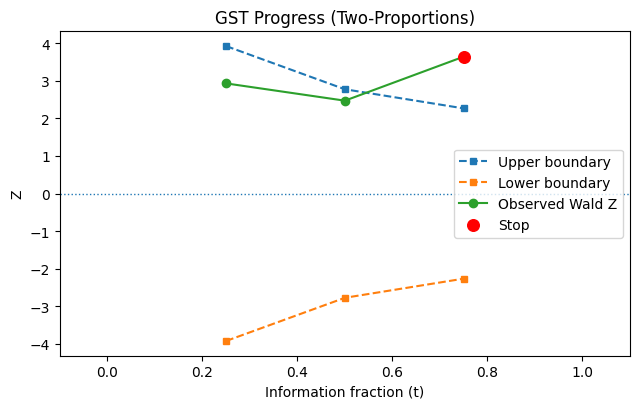

In [6]:
# If running in a notebook, this will render inline
rep.plot()

## Advanced: Creating Custom Experiment Modules

The modular architecture makes it easy to create **portable, shareable experiment definitions**. Here's how to create your own custom modules:

### 1. Custom Module Definition
Analysts can create their own modules by subclassing `ExperimentTemplate` or `TwoPropTemplate`

### 2. Data Ingestion Components
For complex data scenarios, you can still access the underlying ingestion components

### 3. Module Comparison
Compare different experiment designs using the `BatchRunner`